# 📊 Análise Exploratória de Dados (EDA) - ENEM 2024

Este notebook realiza a análise exploratória dos microdados do ENEM 2024, focando em:
- Distribuição das notas por escola
- Análise socioeconômica
- Identificação de padrões para clustering

## 1. Setup - Imports e Configurações

In [2]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Configurar para mostrar mais colunas e linhas
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

# Tamanho padrão de figuras
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## 2. Carregamento de Dados

Carregamos uma amostra inicial de 50.000 registros para análise exploratória.

In [ ]:
# Caminho do arquivo
DATA_PATH = r'C:\Users\leofs\Documents\ciencia_de_dados_2\microdados_enem_2024\DADOS\RESULTADOS_2024.csv'

# Carregar dados com amostragem inicial
df = pd.read_csv(DATA_PATH, sep=';', nrows=100000, encoding='latin-1')

print(f"📊 Dataset carregado!")
print(f"   Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

In [ ]:
# Visualizar primeiras linhas
df.head()

In [ ]:
# Informações básicas do dataset
df.info()

In [6]:
# Listar todas as colunas
print("📋 Colunas disponíveis:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

📋 Colunas disponíveis:
    1. NU_SEQUENCIAL
    2. NU_ANO
    3. CO_ESCOLA
    4. CO_MUNICIPIO_ESC
    5. NO_MUNICIPIO_ESC
    6. CO_UF_ESC
    7. SG_UF_ESC
    8. TP_DEPENDENCIA_ADM_ESC
    9. TP_LOCALIZACAO_ESC
   10. TP_SIT_FUNC_ESC
   11. CO_MUNICIPIO_PROVA
   12. NO_MUNICIPIO_PROVA
   13. CO_UF_PROVA
   14. SG_UF_PROVA
   15. TP_PRESENCA_CN
   16. TP_PRESENCA_CH
   17. TP_PRESENCA_LC
   18. TP_PRESENCA_MT
   19. CO_PROVA_CN
   20. CO_PROVA_CH
   21. CO_PROVA_LC
   22. CO_PROVA_MT
   23. NU_NOTA_CN
   24. NU_NOTA_CH
   25. NU_NOTA_LC
   26. NU_NOTA_MT
   27. TX_RESPOSTAS_CN
   28. TX_RESPOSTAS_CH
   29. TX_RESPOSTAS_LC
   30. TX_RESPOSTAS_MT
   31. TP_LINGUA
   32. TX_GABARITO_CN
   33. TX_GABARITO_CH
   34. TX_GABARITO_LC
   35. TX_GABARITO_MT
   36. TP_STATUS_REDACAO
   37. NU_NOTA_COMP1
   38. NU_NOTA_COMP2
   39. NU_NOTA_COMP3
   40. NU_NOTA_COMP4
   41. NU_NOTA_COMP5
   42. NU_NOTA_REDACAO


## 3. Análise Inicial

Exploramos as estatísticas descritivas, valores únicos e dados faltantes.

### 3.1 Estatísticas Descritivas das Colunas Numéricas

In [7]:
# Selecionar colunas de notas
notas_cols = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

# Estatísticas descritivas
df[notas_cols].describe()

,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
count,34638.000000,36578.000000,36578.000000,34638.000000,36578.000000
mean,493.695369,510.358945,524.222541,526.509790,624.067472
std,78.852678,93.242626,70.156721,114.066863,215.917227
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,431.100000,445.900000,483.800000,430.700000,520.000000
50%,487.400000,515.250000,530.900000,497.200000,640.000000
75%,550.100000,575.400000,571.600000,610.600000,780.000000
max,818.200000,819.700000,795.800000,961.900000,980.000000


### 3.2 Contagem de Valores Únicos nas Colunas Categóricas

In [8]:
# Colunas categóricas de interesse
cat_cols = ['TP_DEPENDENCIA_ADM_ESC', 'TP_LOCALIZACAO_ESC', 'TP_SIT_FUNC_ESC', 
            'SG_UF_ESC', 'SG_UF_PROVA', 'TP_PRESENCA_CN']

print("🔤 Valores únicos por coluna categórica:\n")
for col in cat_cols:
    if col in df.columns:
        unique_count = df[col].nunique(dropna=True)
        print(f"   {col}: {unique_count} valores únicos")
        if unique_count <= 10:
            print(f"      → {df[col].value_counts().to_dict()}")
        print()

🔤 Valores únicos por coluna categórica:

   TP_DEPENDENCIA_ADM_ESC: 4 valores únicos
      → {2.0: 14258, 4.0: 3046, 1.0: 752, 3.0: 93}

   TP_LOCALIZACAO_ESC: 2 valores únicos
      → {1.0: 17243, 2.0: 906}

   TP_SIT_FUNC_ESC: 1 valores únicos
      → {1.0: 18149}

   SG_UF_ESC: 27 valores únicos

   SG_UF_PROVA: 27 valores únicos

   TP_PRESENCA_CN: 3 valores únicos
      → {1: 34638, 0: 15337, 2: 25}



### 3.3 Verificação de Missing Values

In [9]:
# Calcular percentual de missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

# Criar DataFrame com resultados
missing_df = pd.DataFrame({
    'Coluna': missing.index,
    'Missing_Count': missing.values,
    'Missing_Pct': missing_pct.values
})

# Filtrar apenas colunas com missing values
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Pct', ascending=False)

print(f"📊 Colunas com valores faltantes (Total: {len(missing_df)}):\n")
print(missing_df.to_string(index=False))

📊 Colunas com valores faltantes (Total: 31):

                Coluna  Missing_Count  Missing_Pct
             CO_ESCOLA          31851       63.702
      CO_MUNICIPIO_ESC          31851       63.702
      NO_MUNICIPIO_ESC          31851       63.702
             CO_UF_ESC          31851       63.702
             SG_UF_ESC          31851       63.702
TP_DEPENDENCIA_ADM_ESC          31851       63.702
    TP_LOCALIZACAO_ESC          31851       63.702
       TP_SIT_FUNC_ESC          31851       63.702
           CO_PROVA_CN          15362       30.724
            NU_NOTA_CN          15362       30.724
           CO_PROVA_MT          15362       30.724
       TX_RESPOSTAS_MT          15362       30.724
        TX_GABARITO_CN          15362       30.724
       TX_RESPOSTAS_CN          15362       30.724
            NU_NOTA_MT          15362       30.724
        TX_GABARITO_MT          15362       30.724
            NU_NOTA_CH          13422       26.844
           CO_PROVA_CH          1342

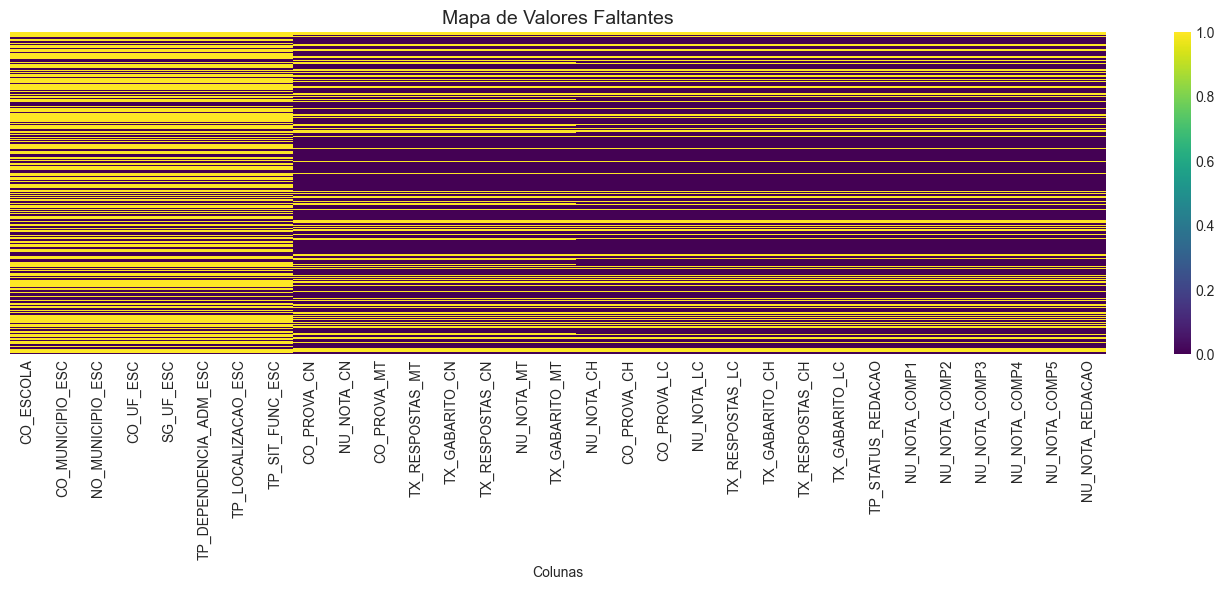

In [10]:
# Visualização de missing values (heatmap para colunas com missing > 0)
if len(missing_df) > 0:
    cols_with_missing = missing_df['Coluna'].tolist()
    
    plt.figure(figsize=(14, 6))
    sns.heatmap(df[cols_with_missing].isnull(), cbar=True, yticklabels=False, cmap='viridis')
    plt.title('Mapa de Valores Faltantes', fontsize=14)
    plt.xlabel('Colunas')
    plt.tight_layout()
    plt.show()

## 4. Análise por Escola

Agregamos os dados por escola para identificar padrões.

### 4.1 Agregação por Escola

In [11]:
# Verificar escolas disponíveis
escolas_com_dados = df['CO_ESCOLA'].notna().sum()
print(f"🏫 Registros com código de escola: {escolas_com_dados:,} ({escolas_com_dados/len(df)*100:.1f}%)")
print(f"   Escolas únicas na amostra: {df['CO_ESCOLA'].nunique():,}")

🏫 Registros com código de escola: 18,149 (36.3%)
   Escolas únicas na amostra: 10,975


In [17]:
# Mapeamento de tipo de escola
# TP_DEPENDENCIA_ADM_ESC: 1=Federal, 2=Estadual, 3=Municipal, 4=Privada
tipo_escola_map = {
    1: 'Federal',
    2: 'Estadual', 
    3: 'Municipal',
    4: 'Privada'
}

# Adicionar coluna de tipo de escola legível
df['TIPO_ESCOLA'] = df['TP_DEPENDENCIA_ADM_ESC'].map(tipo_escola_map)

# Classificar como Pública vs Privada
def classificar_escola(tipo):
    if tipo == 'Privada':
        return 'Privada'
    elif tipo in ['Federal', 'Estadual', 'Municipal']:
        return 'Pública'
    else:
        return 'Não Informado'

df['CATEGORIA_ESCOLA'] = df['TIPO_ESCOLA'].apply(classificar_escola)

print("✅ Classificação de escolas criada!")
print(df['CATEGORIA_ESCOLA'].value_counts())

✅ Classificação de escolas criada!
CATEGORIA_ESCOLA
Não Informado    31851
Pública          15103
Privada           3046
Name: count, dtype: int64


In [18]:
# Agregar dados por escola (apenas escolas identificadas)
df_escolas = df[df['CO_ESCOLA'].notna()].copy()

# Calcular métricas por escola
escola_agg = df_escolas.groupby('CO_ESCOLA').agg({
    'NU_NOTA_CN': 'mean',
    'NU_NOTA_CH': 'mean',
    'NU_NOTA_LC': 'mean',
    'NU_NOTA_MT': 'mean',
    'NU_NOTA_REDACAO': 'mean',
    'NU_SEQUENCIAL': 'count',  # Número de alunos
    'CATEGORIA_ESCOLA': lambda x: x.mode()[0] if not x.mode().empty else 'Não Informado',
    'TIPO_ESCOLA': lambda x: x.mode()[0] if not x.mode().empty else 'Não Informado',
    'SG_UF_ESC': 'first',
    'NO_MUNICIPIO_ESC': 'first'
}).rename(columns={'NU_SEQUENCIAL': 'QTD_ALUNOS'})

# Calcular média geral
escola_agg['MEDIA_GERAL'] = escola_agg[['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']].mean(axis=1)

print(f"📚 Total de escolas analisadas: {len(escola_agg):,}")
print(f"\n📊 Estatísticas das escolas:")
escola_agg.describe()

📚 Total de escolas analisadas: 10,975

📊 Estatísticas das escolas:


,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,QTD_ALUNOS,MEDIA_GERAL
count,9118.000000,9394.000000,9394.000000,9118.000000,9394.000000,10975.000000,9415.000000
mean,486.004386,500.645517,516.417330,518.450531,619.898141,1.653667,527.401065
std,71.020575,83.959553,64.393602,103.526865,203.335358,1.085912,88.551315
min,195.200000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,431.912500,444.600000,479.500000,435.112500,520.000000,1.000000,470.036667
50%,478.450000,500.700000,522.100000,492.900000,640.000000,1.000000,522.760000
75%,534.925000,558.775000,559.700000,584.687500,760.000000,2.000000,585.765000
max,798.700000,795.700000,729.100000,945.100000,980.000000,11.000000,825.940000


### 4.2 Distribuição de Tipo de Escola

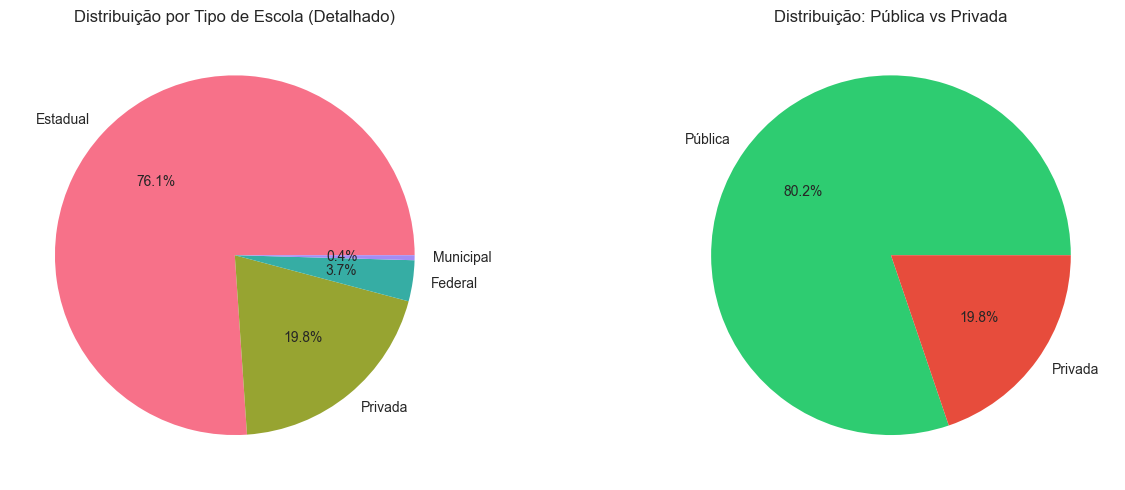

📊 Distribuição de escolas:
TIPO_ESCOLA
Estadual     8350
Privada      2172
Federal       404
Municipal      49
Name: count, dtype: int64


In [16]:
# Distribuição por tipo de escola
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribuição detalhada
tipo_counts = escola_agg['TIPO_ESCOLA'].value_counts()
colors_detailed = sns.color_palette("husl", len(tipo_counts))
axes[0].pie(tipo_counts, labels=tipo_counts.index, autopct='%1.1f%%', colors=colors_detailed)
axes[0].set_title('Distribuição por Tipo de Escola (Detalhado)', fontsize=12)

# Gráfico 2: Pública vs Privada
cat_counts = escola_agg['CATEGORIA_ESCOLA'].value_counts()
colors_cat = ['#2ecc71', '#e74c3c', '#95a5a6']
axes[1].pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%', colors=colors_cat[:len(cat_counts)])
axes[1].set_title('Distribuição: Pública vs Privada', fontsize=12)

plt.tight_layout()
plt.show()

print("📊 Distribuição de escolas:")
print(tipo_counts)

## 5. Visualizações das Notas

### 5.1 Histogramas das Notas

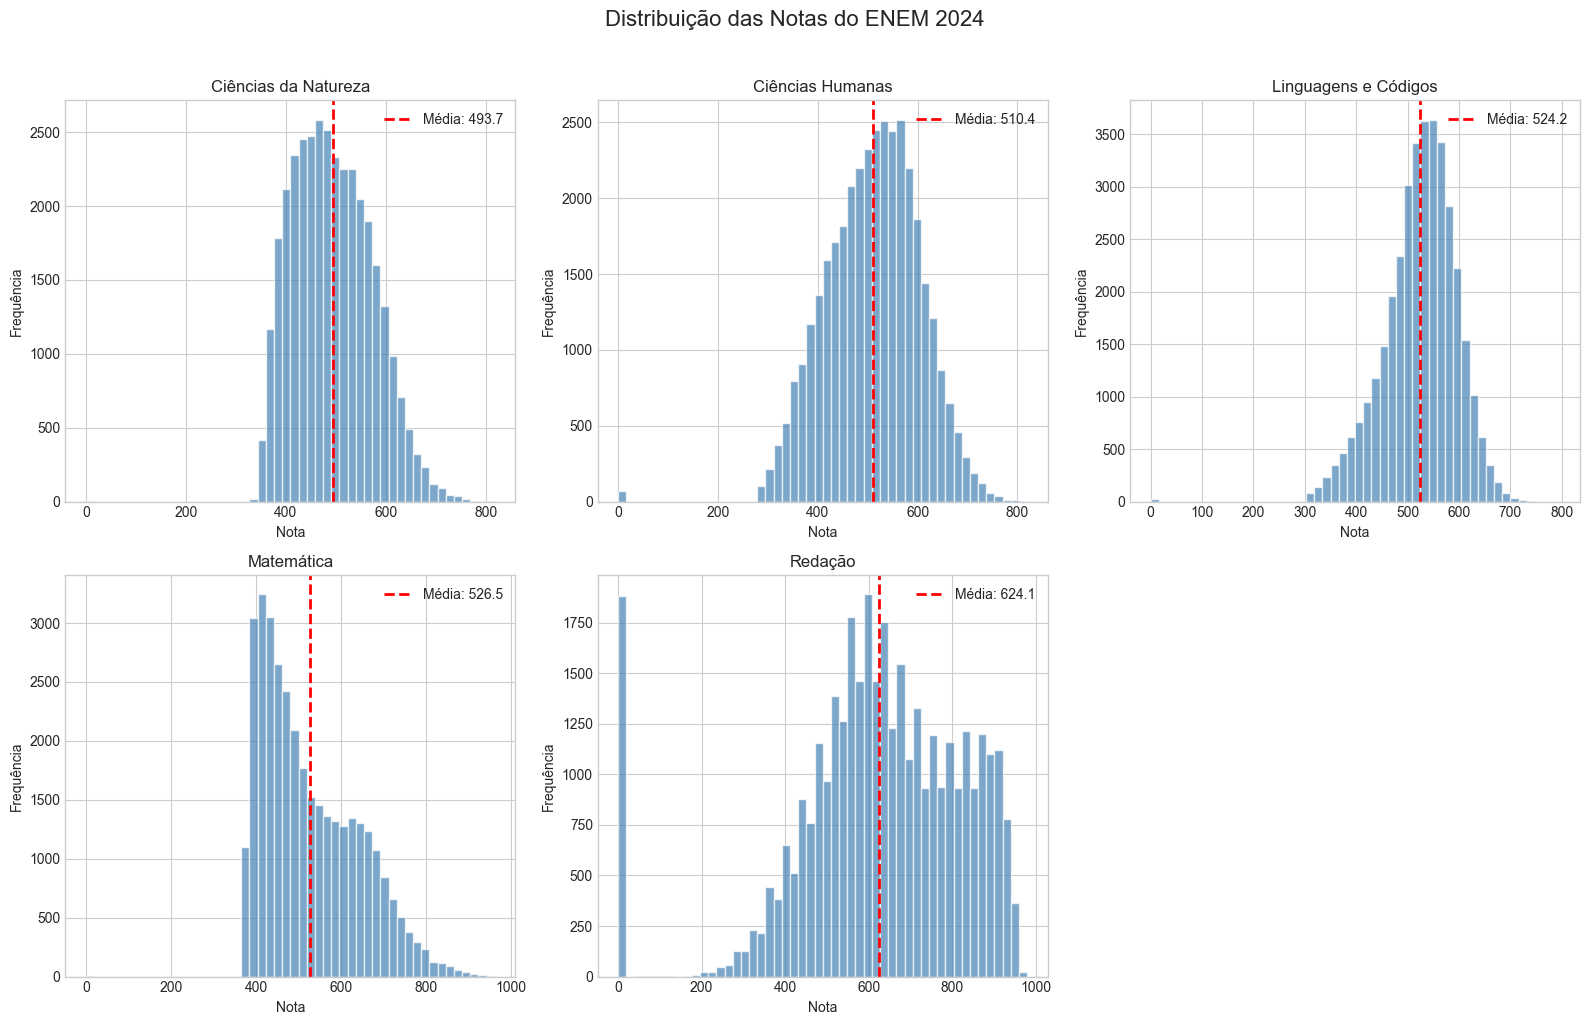

In [19]:
# Histogramas das notas
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

notas_nomes = {
    'NU_NOTA_CN': 'Ciências da Natureza',
    'NU_NOTA_CH': 'Ciências Humanas',
    'NU_NOTA_LC': 'Linguagens e Códigos',
    'NU_NOTA_MT': 'Matemática',
    'NU_NOTA_REDACAO': 'Redação'
}

for i, (col, nome) in enumerate(notas_nomes.items()):
    # Remover valores nulos para o histograma
    data = df[col].dropna()
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
    axes[i].set_title(f'{nome}', fontsize=12)
    axes[i].set_xlabel('Nota')
    axes[i].set_ylabel('Frequência')
    axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Média: {data.mean():.1f}')
    axes[i].legend()

# Remover o último subplot vazio
axes[5].remove()

plt.suptitle('Distribuição das Notas do ENEM 2024', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Boxplots por Tipo de Escola

C:\Users\leofs\AppData\Local\Temp\ipykernel_37080\3427551220.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='CATEGORIA_ESCOLA', y=col, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
C:\Users\leofs\AppData\Local\Temp\ipykernel_37080\3427551220.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='CATEGORIA_ESCOLA', y=col, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
C:\Users\leofs\AppData\Local\Temp\ipykernel_37080\3427551220.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='CATEGORIA_ESCOLA'

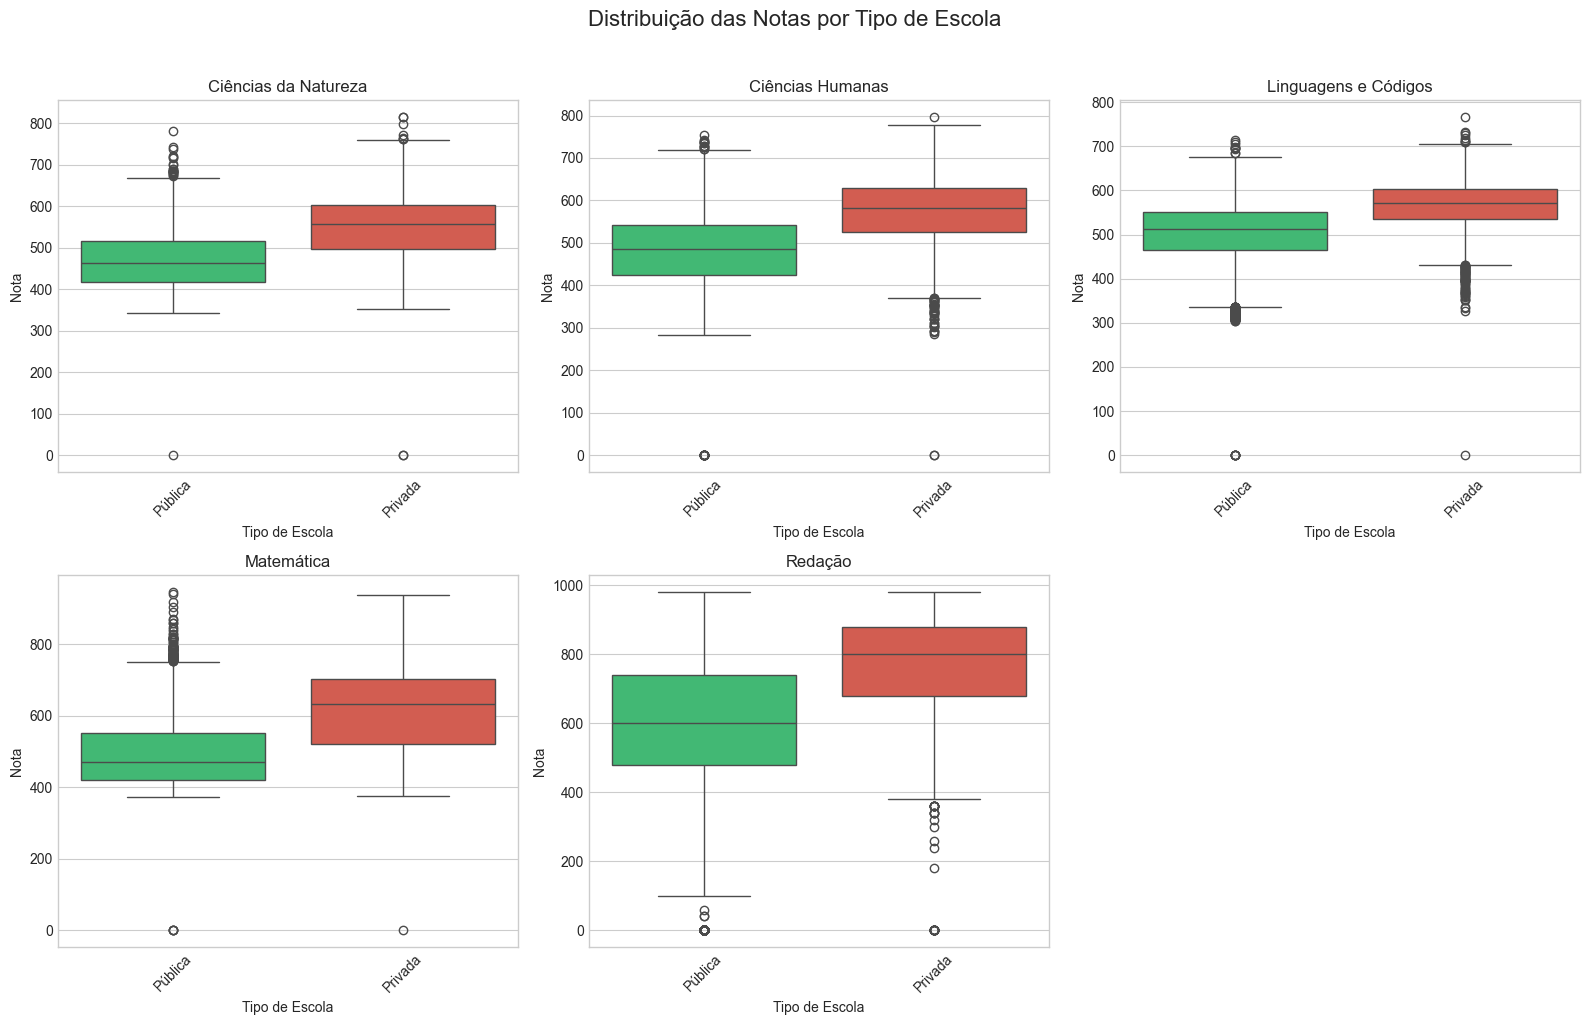

In [20]:
# Boxplots por tipo de escola
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

df_plot = df[df['CATEGORIA_ESCOLA'] != 'Não Informado'].copy()

for i, (col, nome) in enumerate(notas_nomes.items()):
    sns.boxplot(data=df_plot, x='CATEGORIA_ESCOLA', y=col, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{nome}', fontsize=12)
    axes[i].set_xlabel('Tipo de Escola')
    axes[i].set_ylabel('Nota')
    axes[i].tick_params(axis='x', rotation=45)

# Remover o último subplot vazio
axes[5].remove()

plt.suptitle('Distribuição das Notas por Tipo de Escola', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [21]:
# Estatísticas descritivas por tipo de escola
print("📊 Média das notas por tipo de escola:\n")
for col, nome in notas_nomes.items():
    print(f"\n{nome}:")
    stats = df_plot.groupby('CATEGORIA_ESCOLA')[col].agg(['mean', 'median', 'std']).round(2)
    print(stats)

📊 Média das notas por tipo de escola:


Ciências da Natureza:
                    mean  median    std
CATEGORIA_ESCOLA                       
Privada           549.05  556.95  78.72
Pública           469.93  463.70  66.86

Ciências Humanas:
                    mean  median    std
CATEGORIA_ESCOLA                       
Privada           571.78  581.15  83.11
Pública           483.10  486.60  83.47

Linguagens e Códigos:
                    mean  median    std
CATEGORIA_ESCOLA                       
Privada           566.01   571.7  58.02
Pública           504.45   512.8  66.48

Matemática:
                    mean  median     std
CATEGORIA_ESCOLA                        
Privada           615.96   631.5  120.47
Pública           494.69   469.3   93.88

Redação:
                    mean  median     std
CATEGORIA_ESCOLA                        
Privada           768.41   800.0  152.99
Pública           583.63   600.0  222.74


### 5.3 Heatmap de Correlação entre Notas

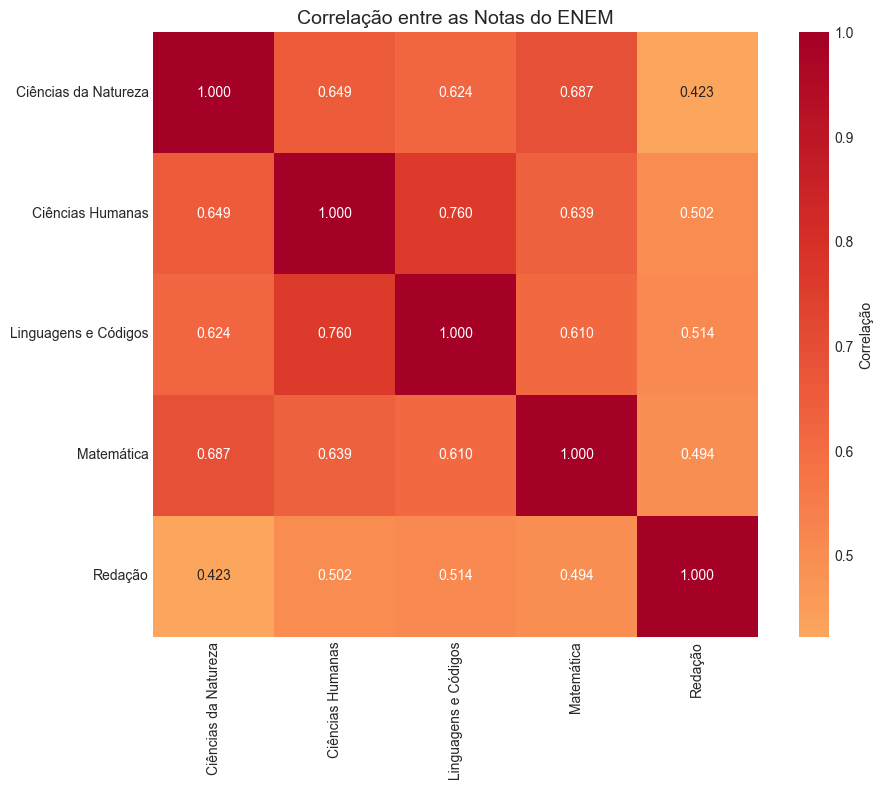

📊 Correlações mais fortes:
   Ciências Humanas × Linguagens e Códigos: 0.760
   Ciências da Natureza × Matemática: 0.687
   Ciências da Natureza × Ciências Humanas: 0.649
   Ciências Humanas × Matemática: 0.639
   Ciências da Natureza × Linguagens e Códigos: 0.624
   Linguagens e Códigos × Matemática: 0.610
   Linguagens e Códigos × Redação: 0.514
   Ciências Humanas × Redação: 0.502
   Matemática × Redação: 0.494
   Ciências da Natureza × Redação: 0.423


In [22]:
# Calcular matriz de correlação
corr_matrix = df[notas_cols].corr()

# Renomear colunas para melhor visualização
corr_matrix.index = [notas_nomes[col] for col in corr_matrix.index]
corr_matrix.columns = [notas_nomes[col] for col in corr_matrix.columns]

# Criar heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0, 
            square=True, fmt='.3f', cbar_kws={'label': 'Correlação'})
plt.title('Correlação entre as Notas do ENEM', fontsize=14)
plt.tight_layout()
plt.show()

print("📊 Correlações mais fortes:")
# Encontrar correlações mais fortes (excluindo diagonal)
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append((
            corr_matrix.index[i], 
            corr_matrix.columns[j], 
            corr_matrix.iloc[i, j]
        ))

corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for area1, area2, corr in corr_pairs:
    print(f"   {area1} × {area2}: {corr:.3f}")

### 5.4 Scatter Plot: Matemática vs Ciências da Natureza

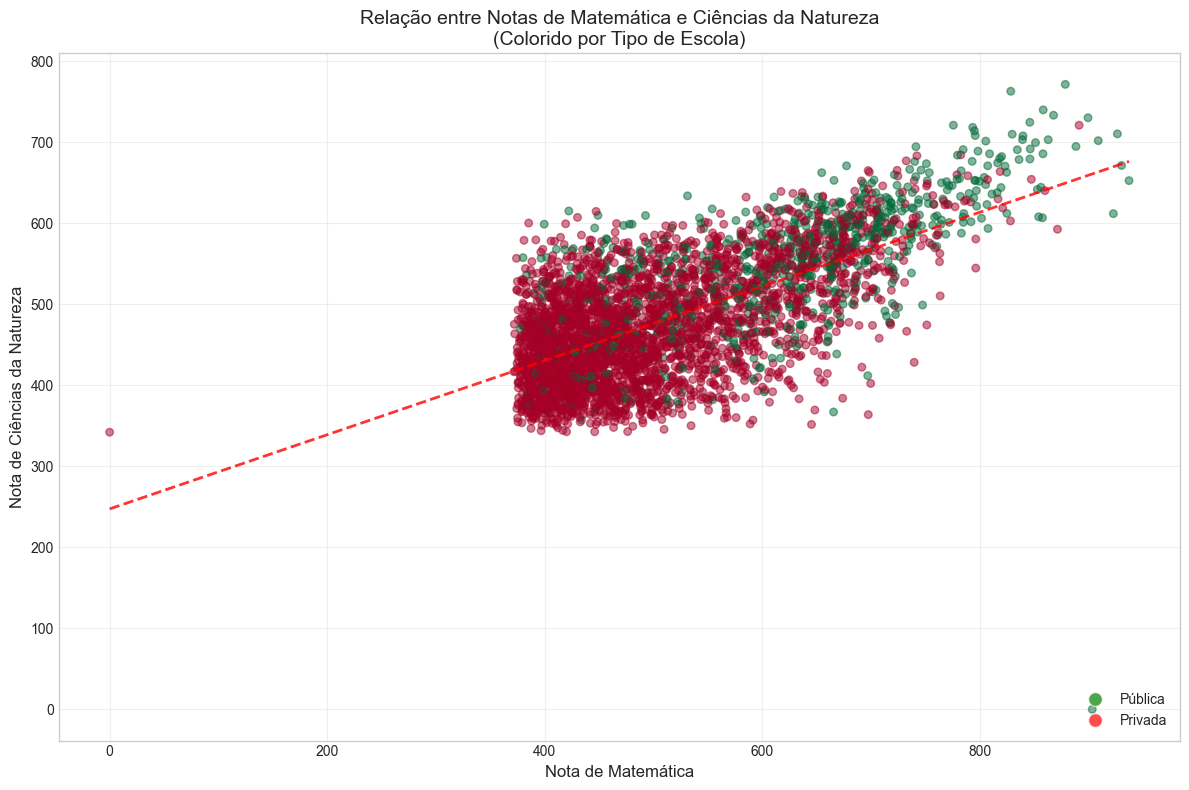

📊 Correlação MT × CN: 0.687


In [23]:
# Scatter plot: MT vs CN colorido por tipo de escola
plt.figure(figsize=(12, 8))

# Amostra para não sobrecarregar o gráfico
df_sample = df_plot.sample(n=min(5000, len(df_plot)), random_state=42)

# Criar scatter plot
scatter = plt.scatter(
    df_sample['NU_NOTA_MT'], 
    df_sample['NU_NOTA_CN'],
    c=df_sample['CATEGORIA_ESCOLA'].map({'Pública': 0, 'Privada': 1}),
    cmap='RdYlGn',
    alpha=0.5,
    s=30
)

plt.xlabel('Nota de Matemática', fontsize=12)
plt.ylabel('Nota de Ciências da Natureza', fontsize=12)
plt.title('Relação entre Notas de Matemática e Ciências da Natureza\n(Colorido por Tipo de Escola)', fontsize=14)

# Adicionar linha de tendência
z = np.polyfit(df_sample['NU_NOTA_MT'].dropna(), 
               df_sample['NU_NOTA_CN'].dropna(), 1)
p = np.poly1d(z)
plt.plot(df_sample['NU_NOTA_MT'].sort_values(), 
         p(df_sample['NU_NOTA_MT'].sort_values()), 
         "r--", alpha=0.8, linewidth=2, label='Tendência')

# Legenda personalizada
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Pública', alpha=0.7),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Privada', alpha=0.7)
]
plt.legend(handles=legend_elements, loc='lower right')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calcular correlação específica
corr_mt_cn = df['NU_NOTA_MT'].corr(df['NU_NOTA_CN'])
print(f"📊 Correlação MT × CN: {corr_mt_cn:.3f}")

## 6. Análise Socioeconômica

Nota: A coluna Q006 (renda familiar) não está disponível no arquivo RESULTADOS_2024.csv.
Vamos verificar quais colunas socioeconômicas estão disponíveis.

In [24]:
# Verificar colunas disponíveis relacionadas a socioeconomia
socio_cols = [col for col in df.columns if 'Q' in col or 'RENDA' in col.upper() or 'SOCIO' in col.upper()]
print("📋 Colunas socioeconômicas disponíveis:")
if socio_cols:
    for col in socio_cols:
        print(f"   - {col}")
else:
    print("   Nenhuma coluna socioeconômica identificada no arquivo RESULTADOS_2024.csv")
    print("\n💡 Nota: Os dados socioeconômicos (Q001-Q025) geralmente estão no arquivo DADOS_MUNICIPIO.csv")

📋 Colunas socioeconômicas disponíveis:
   - NU_SEQUENCIAL


In [25]:
# Como não temos Q006, vamos criar uma análise alternativa usando localização
# Analisar desempenho por UF e tipo de localização

# Análise por UF
uf_stats = df.groupby('SG_UF_PROVA')[notas_cols].mean().round(2)
uf_stats['MEDIA_GERAL'] = uf_stats.mean(axis=1).round(2)
uf_stats = uf_stats.sort_values('MEDIA_GERAL', ascending=False)

print("📊 Média geral por UF (Top 10):")
print(uf_stats.head(10)[['MEDIA_GERAL']])

print("\n📊 Média geral por UF (Bottom 10):")
print(uf_stats.tail(10)[['MEDIA_GERAL']])

📊 Média geral por UF (Top 10):
             MEDIA_GERAL
SG_UF_PROVA             
SP                563.28
DF                561.75
SC                558.57
MG                558.46
ES                558.35
RJ                551.02
PR                549.15
RS                542.88
GO                540.79
MS                533.51

📊 Média geral por UF (Bottom 10):
             MEDIA_GERAL
SG_UF_PROVA             
RR                516.07
BA                515.26
TO                515.04
AC                511.20
AL                507.44
RO                506.11
AP                503.27
MA                499.16
PA                496.82
AM                494.85


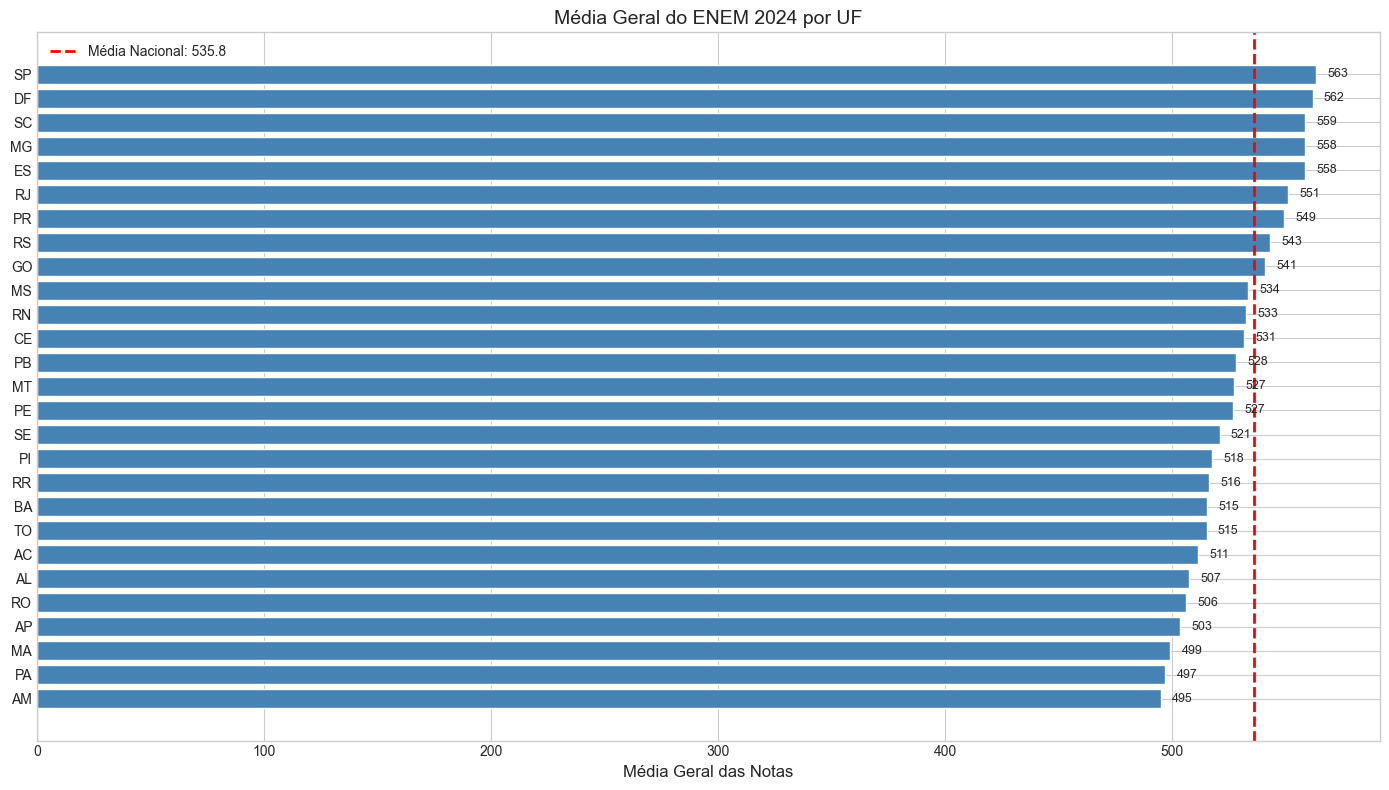

In [26]:
# Visualização: Média geral por UF
plt.figure(figsize=(14, 8))
uf_stats_plot = uf_stats['MEDIA_GERAL'].sort_values(ascending=True)

bars = plt.barh(range(len(uf_stats_plot)), uf_stats_plot.values, color='steelblue', edgecolor='white')
plt.yticks(range(len(uf_stats_plot)), uf_stats_plot.index)
plt.xlabel('Média Geral das Notas', fontsize=12)
plt.title('Média Geral do ENEM 2024 por UF', fontsize=14)

# Adicionar linha de média nacional
media_nacional = df[notas_cols].mean().mean()
plt.axvline(media_nacional, color='red', linestyle='--', linewidth=2, label=f'Média Nacional: {media_nacional:.1f}')
plt.legend()

# Adicionar valores nas barras
for i, (bar, val) in enumerate(zip(bars, uf_stats_plot.values)):
    plt.text(val + 5, i, f'{val:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Análise de Presença

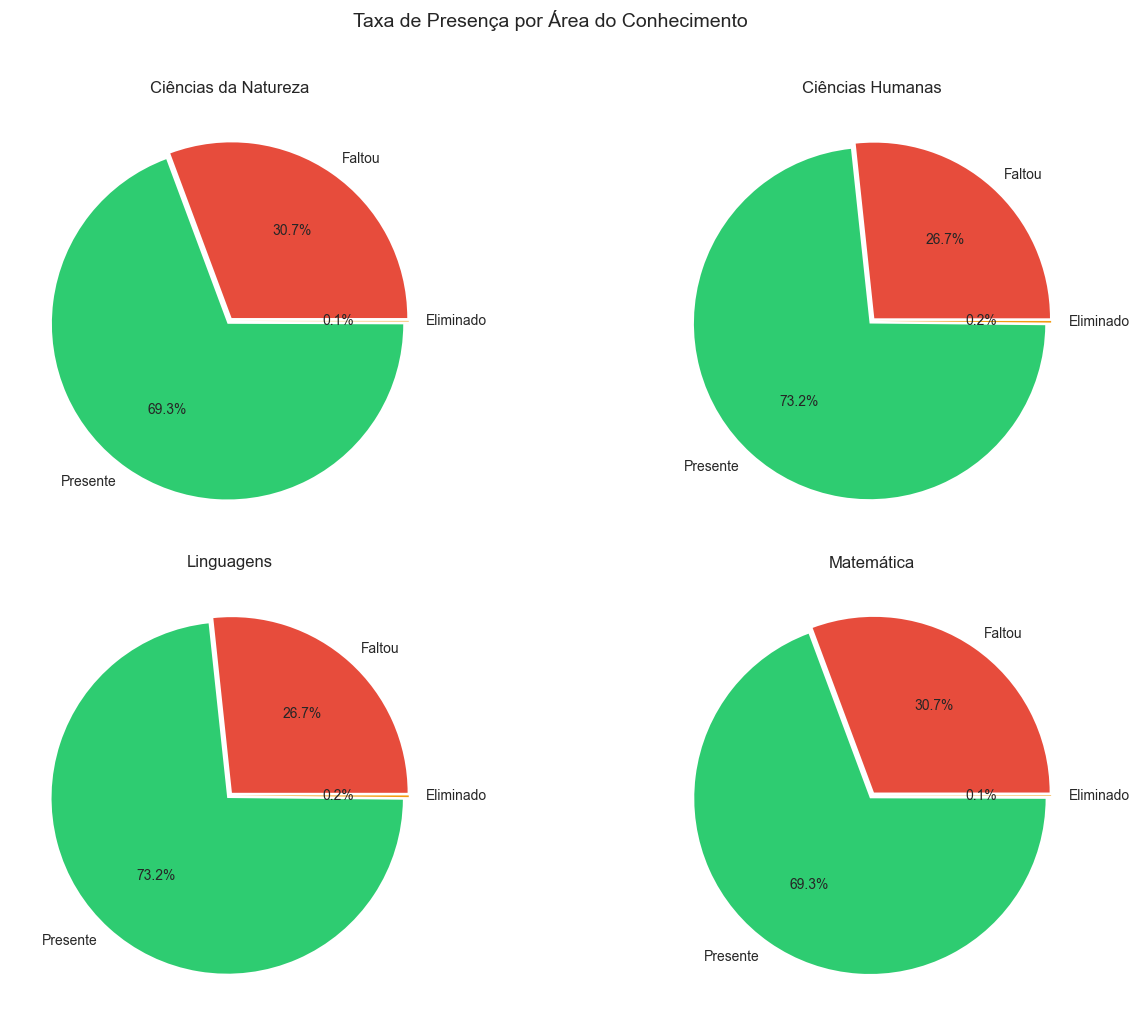

📊 Resumo de presença:
   Ciências da Natureza: 69.3% presentes
   Ciências Humanas: 73.2% presentes
   Linguagens: 73.2% presentes
   Matemática: 69.3% presentes


In [27]:
# Análise de presença nas provas
# TP_PRESENCA: 0=Faltou, 1=Presente, 2=Eliminado

presenca_cols = ['TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT']
presenca_nomes = ['Ciências da Natureza', 'Ciências Humanas', 'Linguagens', 'Matemática']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

presenca_map = {0: 'Faltou', 1: 'Presente', 2: 'Eliminado'}

for i, (col, nome) in enumerate(zip(presenca_cols, presenca_nomes)):
    presenca_counts = df[col].value_counts().sort_index()
    labels = [presenca_map.get(idx, f'Valor {idx}') for idx in presenca_counts.index]
    colors = ['#e74c3c', '#2ecc71', '#f39c12']
    
    wedges, texts, autotexts = axes[i].pie(
        presenca_counts, 
        labels=labels, 
        autopct='%1.1f%%',
        colors=colors[:len(presenca_counts)],
        explode=[0.02]*len(presenca_counts)
    )
    axes[i].set_title(f'{nome}', fontsize=12)

plt.suptitle('Taxa de Presença por Área do Conhecimento', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("📊 Resumo de presença:")
for col, nome in zip(presenca_cols, presenca_nomes):
    presentes = (df[col] == 1).sum()
    total = len(df)
    print(f"   {nome}: {presentes/total*100:.1f}% presentes")

## 8. Insights Iniciais

### 8.1 Qual a distribuição das notas por tipo de escola?

In [28]:
# Análise comparativa por tipo de escola
comparativo = df_plot.groupby('CATEGORIA_ESCOLA')[notas_cols].agg(['mean', 'median']).round(2)

print("📊 RESUMO: Distribuição das Notas por Tipo de Escola\n")
print("="*60)

for col, nome in notas_nomes.items():
    print(f"\n📝 {nome}:")
    pub_mean = comparativo.loc['Pública', (col, 'mean')]
    priv_mean = comparativo.loc['Privada', (col, 'mean')]
    diferenca = priv_mean - pub_mean
    pct_diff = (diferenca / pub_mean) * 100
    
    print(f"   • Escolas Públicas: {pub_mean:.1f} (média)")
    print(f"   • Escolas Privadas: {priv_mean:.1f} (média)")
    print(f"   • Diferença: +{diferenca:.1f} pontos ({pct_diff:+.1f}%) para privadas")

print("\n" + "="*60)
print("\n💡 INSIGHTS:")
print("   1. As escolas privadas apresentam médias consistentemente maiores")
print("   2. A diferença é visível em todas as áreas do conhecimento")
print("   3. A variabilidade das notas também difere entre os grupos")

📊 RESUMO: Distribuição das Notas por Tipo de Escola


📝 Ciências da Natureza:
   • Escolas Públicas: 469.9 (média)
   • Escolas Privadas: 549.0 (média)
   • Diferença: +79.1 pontos (+16.8%) para privadas

📝 Ciências Humanas:
   • Escolas Públicas: 483.1 (média)
   • Escolas Privadas: 571.8 (média)
   • Diferença: +88.7 pontos (+18.4%) para privadas

📝 Linguagens e Códigos:
   • Escolas Públicas: 504.4 (média)
   • Escolas Privadas: 566.0 (média)
   • Diferença: +61.6 pontos (+12.2%) para privadas

📝 Matemática:
   • Escolas Públicas: 494.7 (média)
   • Escolas Privadas: 616.0 (média)
   • Diferença: +121.3 pontos (+24.5%) para privadas

📝 Redação:
   • Escolas Públicas: 583.6 (média)
   • Escolas Privadas: 768.4 (média)
   • Diferença: +184.8 pontos (+31.7%) para privadas


💡 INSIGHTS:
   1. As escolas privadas apresentam médias consistentemente maiores
   2. A diferença é visível em todas as áreas do conhecimento
   3. A variabilidade das notas também difere entre os grupos


### 8.2 Existe correlação entre indicadores geográficos e desempenho?

In [29]:
# Análise por localização da escola
# TP_LOCALIZACAO_ESC: 1=Urbana, 2=Rural

localizacao_map = {1: 'Urbana', 2: 'Rural'}
df_escolas['LOCALIZACAO'] = df_escolas['TP_LOCALIZACAO_ESC'].map(localizacao_map)

if df_escolas['LOCALIZACAO'].notna().any():
    loc_stats = df_escolas.groupby('LOCALIZACAO')[notas_cols].mean().round(2)
    loc_stats['MEDIA_GERAL'] = loc_stats.mean(axis=1).round(2)
    
    print("📊 Média de notas por localização da escola:\n")
    print(loc_stats[['MEDIA_GERAL'] + notas_cols])
    
    # Contagem
    print("\n📊 Quantidade de alunos por localização:")
    print(df_escolas['LOCALIZACAO'].value_counts())
else:
    print("⚠️ Dados de localização não disponíveis na amostra")

📊 Média de notas por localização da escola:

             MEDIA_GERAL  NU_NOTA_CN  NU_NOTA_CH  NU_NOTA_LC  NU_NOTA_MT  \
LOCALIZACAO                                                                
Rural             487.70      465.10      465.00      485.64      482.81   
Urbana            530.59      487.12      502.38      518.12      521.24   

             NU_NOTA_REDACAO  
LOCALIZACAO                   
Rural                 539.97  
Urbana                624.08  

📊 Quantidade de alunos por localização:
LOCALIZACAO
Urbana    17243
Rural       906
Name: count, dtype: int64


📊 Análise por Dependência Administrativa:

             NU_NOTA_CN  NU_NOTA_CH  NU_NOTA_LC  NU_NOTA_MT  NU_NOTA_REDACAO  \
TIPO_ESCOLA                                                                    
Privada          549.05      571.78      566.01      615.96           768.41   
Federal          525.93      543.22      550.40      578.69           717.66   
Municipal        492.21      512.62      529.07      536.46           611.22   
Estadual         466.01      478.95      501.27      488.75           574.68   

             MEDIA_GERAL  QTD_ALUNOS  
TIPO_ESCOLA                           
Privada           614.24        3046  
Federal           583.18         752  
Municipal         536.32          93  
Estadual          501.93       14258  


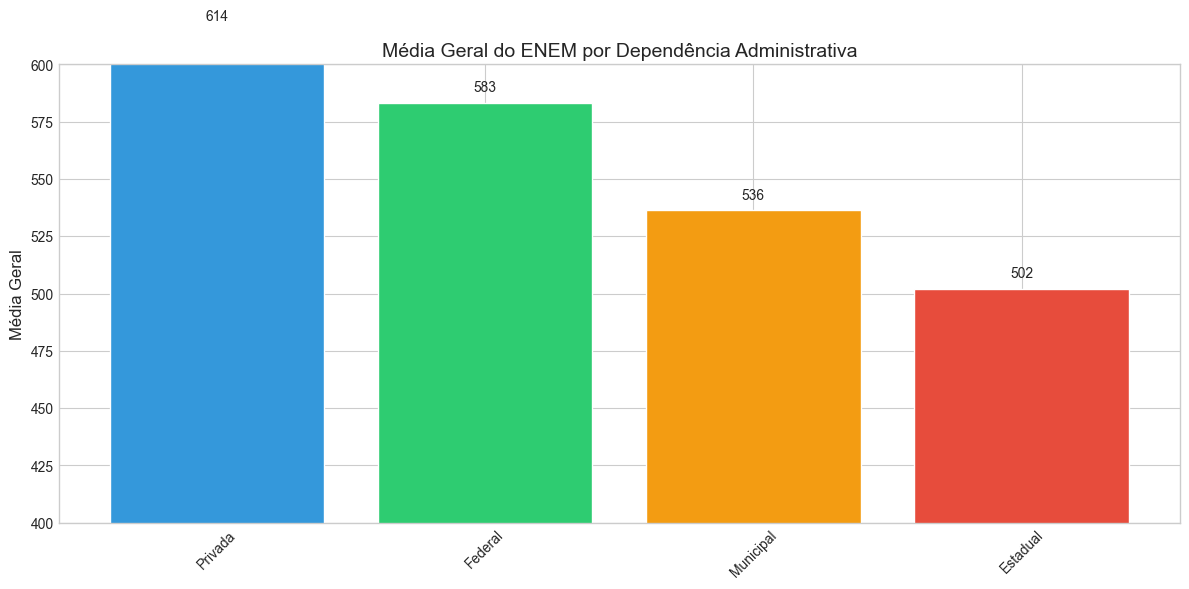

In [30]:
# Análise por dependência administrativa
print("📊 Análise por Dependência Administrativa:\n")
dep_stats = df_escolas.groupby('TIPO_ESCOLA')[notas_cols].mean().round(2)
dep_stats['MEDIA_GERAL'] = dep_stats.mean(axis=1).round(2)
dep_stats['QTD_ALUNOS'] = df_escolas.groupby('TIPO_ESCOLA').size()

print(dep_stats.sort_values('MEDIA_GERAL', ascending=False))

# Visualização
plt.figure(figsize=(12, 6))
media_geral_by_tipo = dep_stats['MEDIA_GERAL'].sort_values(ascending=False)
colors = ['#2ecc71' if t == 'Federal' else '#3498db' if t == 'Privada' else '#e74c3c' if t == 'Estadual' else '#f39c12' for t in media_geral_by_tipo.index]

bars = plt.bar(range(len(media_geral_by_tipo)), media_geral_by_tipo.values, color=colors, edgecolor='white')
plt.xticks(range(len(media_geral_by_tipo)), media_geral_by_tipo.index, rotation=45)
plt.ylabel('Média Geral', fontsize=12)
plt.title('Média Geral do ENEM por Dependência Administrativa', fontsize=14)
plt.ylim(400, 600)

# Adicionar valores nas barras
for bar, val in zip(bars, media_geral_by_tipo.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 5, f'{val:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 9. Resumo e Conclusões

In [31]:
# Resumo final
print("="*70)
print("📊 RESUMO DA ANÁLISE EXPLORATÓRIA - ENEM 2024")
print("="*70)

print(f"\n📋 DADOS ANALISADOS:")
print(f"   • Total de registros: {len(df):,}")
print(f"   • Escolas identificadas: {df['CO_ESCOLA'].nunique():,}")
print(f"   • Municípios: {df['NO_MUNICIPIO_PROVA'].nunique():,}")
print(f"   • UFs: {df['SG_UF_PROVA'].nunique()}")

print(f"\n📈 MÉDIAS GERAIS:")
for col, nome in notas_nomes.items():
    media = df[col].mean()
    print(f"   • {nome}: {media:.1f}")

print(f"\n🏫 DISTRIBUIÇÃO POR TIPO DE ESCOLA:")
tipo_dist = df['CATEGORIA_ESCOLA'].value_counts()
for tipo, qtd in tipo_dist.items():
    pct = qtd / len(df) * 100
    print(f"   • {tipo}: {qtd:,} ({pct:.1f}%)")

print(f"\n📊 DIFERENÇA PÚBLICA vs PRIVADA:")
pub_media = df_plot[df_plot['CATEGORIA_ESCOLA'] == 'Pública'][notas_cols].mean().mean()
priv_media = df_plot[df_plot['CATEGORIA_ESCOLA'] == 'Privada'][notas_cols].mean().mean()
print(f"   • Média Pública: {pub_media:.1f}")
print(f"   • Média Privada: {priv_media:.1f}")
print(f"   • Diferença: {priv_media - pub_media:+.1f} pontos ({(priv_media/pub_media-1)*100:+.1f}%)")

print(f"\n🔗 CORRELAÇÕES MAIS FORTES:")
corr_pairs_top = [(a, b, c) for a, b, c in corr_pairs[:3]]
for area1, area2, corr in corr_pairs_top:
    print(f"   • {area1} × {area2}: {corr:.3f}")

print("\n" + "="*70)
print("✅ ANÁLISE CONCLUÍDA!")
print("="*70)

📊 RESUMO DA ANÁLISE EXPLORATÓRIA - ENEM 2024

📋 DADOS ANALISADOS:
   • Total de registros: 50,000
   • Escolas identificadas: 10,975
   • Municípios: 1,705
   • UFs: 27

📈 MÉDIAS GERAIS:
   • Ciências da Natureza: 493.7
   • Ciências Humanas: 510.4
   • Linguagens e Códigos: 524.2
   • Matemática: 526.5
   • Redação: 624.1

🏫 DISTRIBUIÇÃO POR TIPO DE ESCOLA:
   • Não Informado: 31,851 (63.7%)
   • Pública: 15,103 (30.2%)
   • Privada: 3,046 (6.1%)

📊 DIFERENÇA PÚBLICA vs PRIVADA:
   • Média Pública: 507.2
   • Média Privada: 614.2
   • Diferença: +107.1 pontos (+21.1%)

🔗 CORRELAÇÕES MAIS FORTES:
   • Ciências Humanas × Linguagens e Códigos: 0.760
   • Ciências da Natureza × Matemática: 0.687
   • Ciências da Natureza × Ciências Humanas: 0.649

✅ ANÁLISE CONCLUÍDA!


---

## Próximos Passos para Clustering

Com base nesta EDA, os próximos passos para o projeto de clustering serão:

1. **Preparação dos dados**:
   - Tratar valores faltantes
   - Normalizar features
   - Selecionar variáveis relevantes

2. **Features para clustering**:
   - Médias das notas por escola
   - Número de alunos (tamanho da escola)
   - Tipo de escola (categórica)
   - Localização geográfica
   - Taxa de participação

3. **Algoritmos a testar**:
   - K-Means
   - DBSCAN
   - Hierarchical Clustering
   - Gaussian Mixture Models